<a href="https://colab.research.google.com/github/gpreti/EE-629/blob/main/EX2/EX_dFC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ========================================
# DYNAMIC FUNCTIONAL CONNECTIVITY EXERCISE
# ========================================

# ===================== LIBRARIES =====================
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.stats import zscore

# ============================
# Clone entire Github repository
# ============================

!git clone https://github.com/gpreti/EE-629.git

print("Repository cloned.") #everything exist locally now, path: "EE-629/EX2/"



Cloning into 'EE-629'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 228 (delta 5), reused 1 (delta 1), pack-reused 202 (from 1)
Receiving objects: 100% (228/228), 73.75 MiB | 27.95 MiB/s, done.
Resolving deltas: 100% (53/53), done.
Repository cloned.


In [6]:
path_exercise='EE-629/EX2/'

# ===================== LOAD TIMECOURSES =====================
tcs_file = os.path.join(path_exercise, 'DATA', 'TCS.mat')
tcs = scipy.io.loadmat(tcs_file)
print("Variables in .mat file:", tcs.keys())

# Extract the main timecourse variable
TCSvar = tcs['X1']  # shape: (regions, timepoints, subjects)
print("TCS shape (regions x timepoints x subjects):", TCSvar.shape)

n_regions, n_timepoints, n_subjects = TCSvar.shape

Variables in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'X1'])
TCS shape (regions x timepoints x subjects): (379, 1200, 5)


In [7]:
# ===================== FUNCTION TO COMPUTE SLIDING-WINDOW DFC =====================

def sliding_window_dfc(TCS, window_size, step, fisher_z=False):
    """
    Compute sliding window dynamic functional connectivity (Pearson correlation).

    Parameters
    ----------
    TCS : np.ndarray
        Timecourses matrix of shape (n_regions, n_timepoints)
    window_size : int
        Window length in TRs
    step : int
        Step size to move the window (in TRs)
    fisher_z : bool
        If True, apply Fisher z-transform to correlations

    Returns
    -------
    dFC : np.ndarray
        Dynamic FC array of shape (n_windows, n_regions, n_regions)
    win_starts : list
        Starting indices of each window
    """

    n_regions, n_timepoints = TCS.shape

    # Compute window start indices
    win_starts = list(range(0, n_timepoints - window_size + 1, step))
    n_windows = len(win_starts)

    # Preallocate output
    dFC = np.zeros((n_windows, n_regions, n_regions))

    for i, start in enumerate(win_starts):
        end = start + window_size

        # Extract windowed data
        window_data = TCS[:, start:end]

        # Compute correlation matrix
        corr_matrix = np.corrcoef(window_data)

        if fisher_z:
            # Avoid infinite values
            corr_matrix = np.clip(corr_matrix, -0.999999, 0.999999)
            corr_matrix = np.arctanh(corr_matrix)

        dFC[i] = corr_matrix

    return dFC, win_starts

In [8]:
TCSvar.shape

(379, 1200, 5)

In [9]:
#compute dFC: define parameters window size and step in TR!
window_size = 60
step = 5

dFC, starts = sliding_window_dfc(TCSvar[:, :, 0], window_size, step) # run dFC function for subject 1
n_windows = dFC.shape[0]
print(n_windows)

229


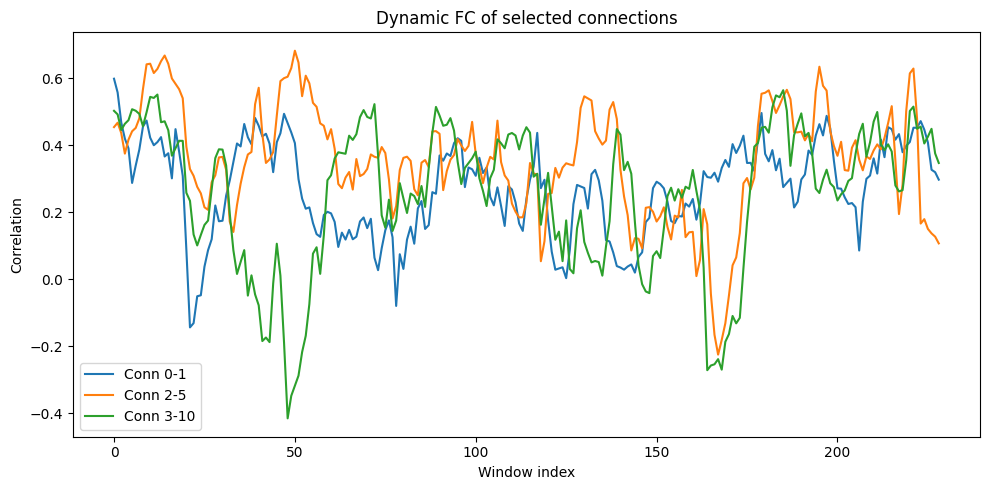

In [10]:
#Plot timecourse of selected connections
connections = [(0, 1), (2, 5), (3, 10)]  # choose some pairs

plt.figure(figsize=(10, 5))

for (i, j) in connections:
    plt.plot(dFC[:, i, j], label=f'Conn {i}-{j}')

plt.xlabel("Window index")
plt.ylabel("Correlation")
plt.title("Dynamic FC of selected connections")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_217/1997512572.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


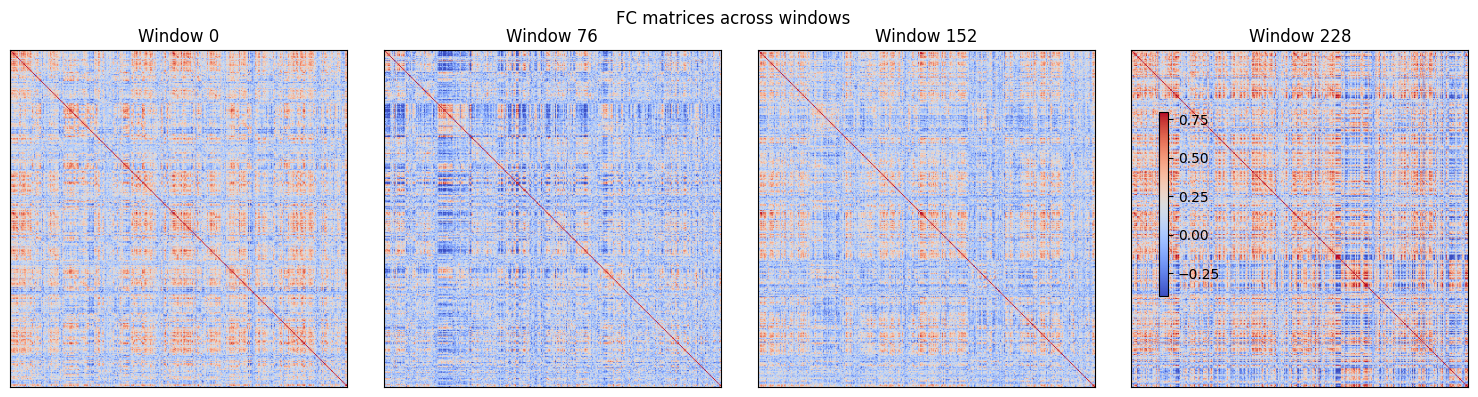

In [11]:

#Plot few FC matrices from different windows to check variations

windows_to_plot = [0, n_windows//3, 2*n_windows//3, n_windows-1]

fig, axes = plt.subplots(1, len(windows_to_plot), figsize=(15, 4))

for ax, w in zip(axes, windows_to_plot):
    im = ax.imshow(dFC[w], vmin=-0.4, vmax=0.8, cmap='coolwarm')
    ax.set_title(f'Window {w}')
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.suptitle("FC matrices across windows")
plt.tight_layout()
plt.show()

In [13]:
#Which connections vary the most in your group?

# 1) Compute dynamic FC for each subject

all_dFC = []

for s in range(n_subjects):
    TCS_sub = TCSvar[:, :, s]  # (regions x timepoints)
    dFC, _ = sliding_window_dfc(TCS_sub, window_size, step, fisher_z=True)
    all_dFC.append(dFC)

all_dFC = np.array(all_dFC)  # shape: (n_subjects, n_windows, n_regions, n_regions)
n_windows = all_dFC.shape[1]

print("Dynamic FC array shape:", all_dFC.shape)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Dynamic FC array shape: (5, 229, 379, 379)


In [14]:

# 2) Compute connection-wise variance across windows (per subject)

# variance along windows
var_conn = np.var(all_dFC, axis=1)  # shape: (n_subjects, n_regions, n_regions)


# 3) One-sample t-test vs 0 (across subjects)


from scipy.stats import ttest_1samp
t_vals = np.zeros((n_regions, n_regions))
p_vals = np.zeros((n_regions, n_regions))

for i in range(n_regions):
    for j in range(n_regions):
        t_stat, p_val = ttest_1samp(var_conn[:, i, j], 0)
        t_vals[i, j] = t_stat
        p_vals[i, j] = p_val



/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [15]:

# 4) Threshold for significance (uncorrected, alpha=0.05)

alpha = 0.001
signif_mask = p_vals < alpha

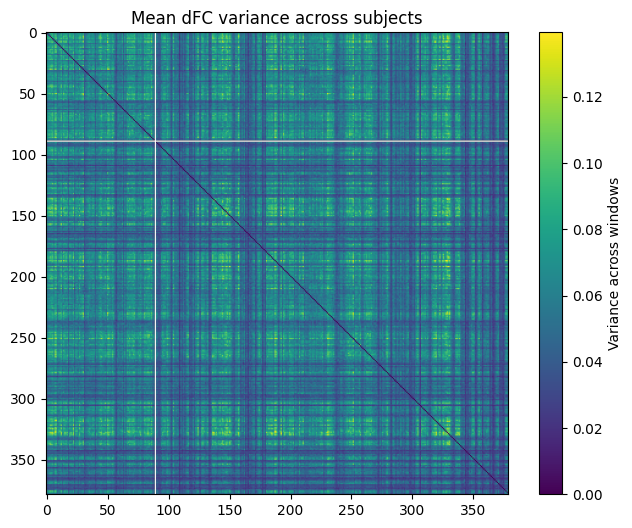

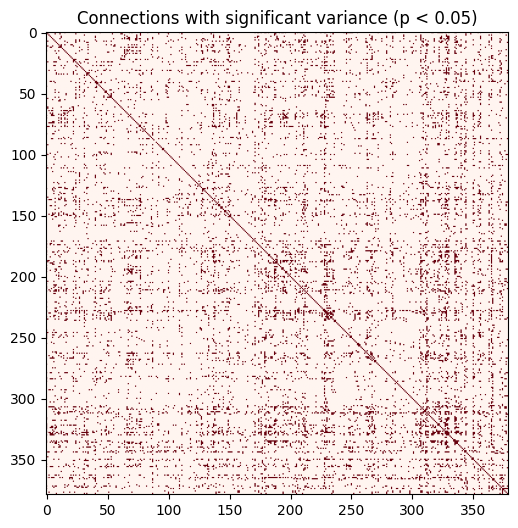

Number of significant connections: 11190


In [16]:

# 5) Visualize

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(var_conn.mean(axis=0), cmap='viridis')
plt.colorbar(label='Variance across windows')
plt.title('Mean dFC variance across subjects')
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(signif_mask, cmap='Reds')
plt.title('Connections with significant variance (p < 0.05)')
plt.show()

print(f"Number of significant connections: {np.sum(signif_mask)}")